# Introduction
This web site is running a "Jupyter notebook," which allows you to execute interactive Octave
code directly in your browser. Each (part of a code) line preceeded by a percent symbol "%" is a code comment.

To execute any Octave commands, first enter the commands in a code cell, and then depress the "shift" and "enter" keys on your keyboard at the same time, making sure that your cursor is placed inside of the code cell.
I refer to this as "< shift \> < enter \>" in my instructions below.

The output from this notebook will be used to provide answers for this lesson's practice
quiz. As you proceed through the specialization, you will use more and more Jupyter notebooks
to write Octave code to implement Kalman-filter algorithms.

In [2]:
% Place your cursor in this input code cell. Then, type < shift >< enter > to execute

% Load data from simulation of system dynamic model. These data were created by the code in 
% Lesson 1.4.2, and are the same data used in Lesson 1.4.3.
%
% Data file contains Ad Bd Cd Dd SigmaV SigmaW dT t u x z
load readonly/simOut.mat

### Implementing the standard Kalman filter
The next notebook cells implement the standard Kalman filter, for comparison with the square-root Kalman filter.

In [3]:
% Determine number of states and timesteps
[nx,nt] = size(x); 

In [4]:
xhatKFstore = zeros(nx,nt);  % Reserve storage for all KF state estimates and their
boundKFstore = zeros(nx,nt); %  confidence bounds for the standard Kalman filter (KF)

% Initialize state estimate and covariance
xhat = zeros(nx,1); SigmaX = 1e-10*eye(nx); % SigmaX must be positive definite
                             
xhatKFstore(:,1) = xhat;     % Store in data structure
boundKFstore(:,1)=3*sqrt(diag(SigmaX));

for k = 2:nt
  % KF Step 1a: State estimate time update      
  xhat = Ad*xhat + Bd*u(k-1); % use prior value of "u"
 
  % KF Step 1b: Error covariance time update   
  SigmaX = Ad*SigmaX*Ad' + SigmaW;
  
  % KF Step 1c: Estimate system output   
  zhat = Cd*xhat + Dd*u(k); % use present value of "u"

  % KF Step 2a: Compute Kalman gain matrix   
  L = SigmaX*Cd'/(Cd*SigmaX*Cd' + SigmaV);
 
  % KF Step 2b: State estimate measurement update   
  xhat = xhat + L*(z(k) - zhat);
   
  % KF Step 2c: Error covariance measurement update   
  SigmaX = (eye(nx)-L*Cd)*SigmaX;
 
  % [Store information for evaluation/plotting purposes]  
  xhatKFstore(:,k) = xhat; 
  boundKFstore(:,k) = 3*sqrt(diag(SigmaX));
end

### Implementing the square-root Kalman filter
The next notebook cells implement the square-root Kalman filter, for comparison with the standard Kalman filter.

In [5]:
% Initialize simulation variables 
SRSigmaW = chol(SigmaW,'lower'); % Square-root process noise covar
SRSigmaV = chol(SigmaV,'lower'); % Square-root sensor noise covar
SigmaX = 1e-10*eye(nx);          % Same SigmaX as for standard KF for comparison
SRSigmaX = chol(SigmaX,'lower'); % Square-root initial-state uncertainty

In [6]:
xhatSRKFstore = zeros(nx,nt);  % Reserve storage for all KF state estimates and their
boundSRKFstore = zeros(nx,nt); %  confidence bounds for the square-root Kalman filter (SRKF)

% Initialize state estimate and covariance
xhat = zeros(nx,1); 
                             
xhatSRKFstore(:,1) = xhat;     % Store in data structure
boundSRKFstore(:,1)=3*sqrt(diag(SigmaX));

for k = 2:length(t)
  % SR-KF Step 1a: State prediction time update   
  xhat = Ad*xhat + Bd*u(:,k-1); % use prior value of "u"
 
  % SR-KF Step 1b: Error covariance time update   
  SRSigmaX = qr([Ad*SRSigmaX, SRSigmaW]')';
  SRSigmaX = tril(SRSigmaX(1:nx,1:nx));
 
  % SR-KF Step 1c: Predict system output 
  zhat = Cd*xhat + Dd*u(:,k);
 
  % SR-KF Step 2a: Compute estimator (Kalman) gain matrix
  % Note: "help mrdivide" to see how "division" is implemented   
  SRSigmaZ = qr([Cd*SRSigmaX,SRSigmaV]')';    
  SRSigmaZ = tril(SRSigmaZ(1:length(zhat),1:length(zhat)));
  L = (SRSigmaX*SRSigmaX')*Cd'/SRSigmaZ'/SRSigmaZ;
 
  % SR-KF Step 2b: State estimate measurement update   
  xhat = xhat + L*(z(:,k) - zhat);
    
  % SR-KF Step 2c: Estimation-error covariance measurement update
  Sx_ = SRSigmaX'; 
  cov_update_vectors = L*SRSigmaZ; 
  for j=1:length(zhat)
    Sx_ = cholupdate(Sx_,cov_update_vectors(:,j),'-');
  end
  SRSigmaX = Sx_'; 
 
  % [Store information for evaluation/plotting purposes]  
  xhatSRKFstore(:,k) = xhat;
  boundSRKFstore(:,k) = 3*sqrt(diag(SRSigmaX*SRSigmaX')); 
end

### Plot simulation outputs from standard and square-root Kalman-filters
The next notebook cells plot the state-vector estimates and the estimation errors (with bounds).

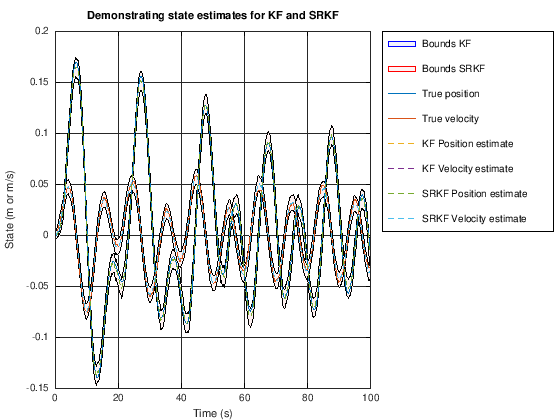

In [7]:
% Plot the states with confidence bounds
t2 = [t fliplr(t)]; % Prepare for plotting bounds via "fill"
x2 = [xhatKFstore-boundKFstore fliplr(xhatKFstore+boundKFstore)];
h1a = fill(t2,x2(1,:),'b',"FaceAlpha",0.05); hold on; grid on
fill(t2,x2(2,:),'b',"FaceAlpha",0.05); 

x3 = [xhatSRKFstore-boundSRKFstore fliplr(xhatSRKFstore+boundSRKFstore)];
h2a = fill(t2,x3(1,:),'r',"FaceAlpha",0.05); hold on; grid on
fill(t2,x3(2,:),'r',"FaceAlpha",0.05); 

h2 = plot(t,x',t,xhatKFstore','--'); 
h3 = plot(t,xhatSRKFstore','--'); ylim([-0.15 0.2]);
legend([h2;h3;h1a;h2a],{'True position','True velocity','KF Position estimate',...
  'KF Velocity estimate','SRKF Position estimate',...
  'SRKF Velocity estimate','Bounds KF','Bounds SRKF'},'Location','BestOutside'); 
title('Demonstrating state estimates for KF and SRKF'); 
xlabel('Time (s)'); ylabel('State (m or m/s)'); 

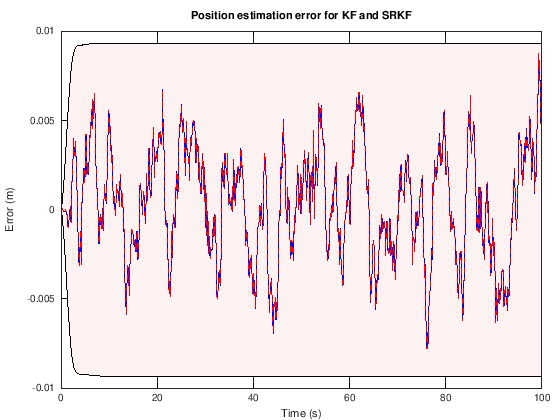

In [8]:
xerrKF = x - xhatKFstore; 
xerrSRKF = x - xhatSRKFstore; 
fill([t fliplr(t)],[-boundKFstore(1,:) fliplr(boundKFstore(1,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
fill([t fliplr(t)],[-boundSRKFstore(1,:) fliplr(boundSRKFstore(1,:))],'r',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,xerrKF(1,:),'b',t,xerrSRKF(1,:),'r--');
title('Position estimation error for KF and SRKF'); 
xlabel('Time (s)'); ylabel('Error (m)'); 

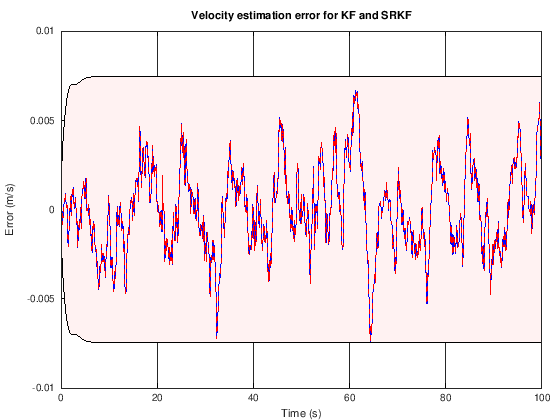

In [9]:
fill([t fliplr(t)],[-boundKFstore(2,:) fliplr(boundKFstore(2,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
fill([t fliplr(t)],[-boundSRKFstore(2,:) fliplr(boundSRKFstore(2,:))],'r',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,xerrKF(2,:),'b',t,xerrSRKF(2,:),'r--');
title('Velocity estimation error for KF and SRKF'); 
xlabel('Time (s)'); ylabel('Error (m/s)'); 